# Hello World TFLite — Treinamento e Avaliação
Adaptado de: https://github.com/tensorflow/tflite-micro/blob/main/tensorflow/lite/micro/examples/hello_world/train.py

In [1]:
!pip install tensorflow numpy matplotlib --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

In [2]:
import math
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## 1. Geração de dados

Treino: 900 | Validação: 300 | Teste: 300


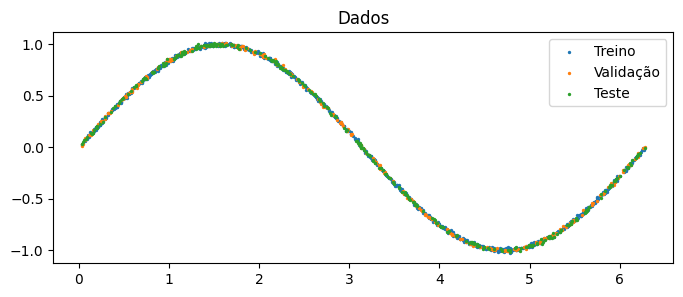

In [3]:
SAMPLES = 1500   # original: 1000
SEED    = 42

np.random.seed(SEED)

x_all = np.random.uniform(low=0, high=2 * math.pi, size=SAMPLES).astype(np.float32)
y_all = np.sin(x_all).astype(np.float32)
y_all += 0.01 * np.random.randn(*y_all.shape).astype(np.float32)   # pequeno ruído

idx   = np.random.permutation(len(x_all))
x_all = x_all[idx]
y_all = y_all[idx]

# Split: 60% treino | 20% validação | 20% teste
n     = len(x_all)
n_tr  = int(n * 0.60)
n_val = int(n * 0.20)

x_train, y_train = x_all[:n_tr],        y_all[:n_tr]
x_val,   y_val   = x_all[n_tr:n_tr+n_val], y_all[n_tr:n_tr+n_val]
x_test,  y_test  = x_all[n_tr+n_val:],  y_all[n_tr+n_val:]

print(f"Treino: {len(x_train)} | Validação: {len(x_val)} | Teste: {len(x_test)}")

plt.figure(figsize=(8, 3))
plt.scatter(x_train, y_train, s=2, label='Treino')
plt.scatter(x_val,   y_val,   s=2, label='Validação')
plt.scatter(x_test,  y_test,  s=2, label='Teste')
plt.legend(); plt.title('Dados'); plt.show()

## 2. Criação do modelo

In [4]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(1,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae'],
    )
    return model

model = create_model()
model.summary()

/Users/emanoelspanhol/Pojetos/IAEmbarcada/Projeto2/hello_world_tflite/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Treinamento

Epoch 1/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3846 - mae: 0.5324 - val_loss: 0.3722 - val_mae: 0.5243
Epoch 2/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3419 - mae: 0.5035 - val_loss: 0.3280 - val_mae: 0.4938
Epoch 3/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2929 - mae: 0.4644 - val_loss: 0.2650 - val_mae: 0.4465
Epoch 4/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2359 - mae: 0.4209 - val_loss: 0.2308 - val_mae: 0.4125
Epoch 5/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2051 - mae: 0.3920 - val_loss: 0.2008 - val_mae: 0.3871
Epoch 6/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1831 - mae: 0.3719 - val_loss: 0.1784 - val_mae: 0.3683
Epoch 7/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1660 - mae: 0.3560 - val_loss: 0.1651 - val_mae: 0.3575
Epoch 8/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1567 - mae: 0.3457 - val_loss: 0.1604 - val_mae: 0.3425
Epoch 9/600
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.148

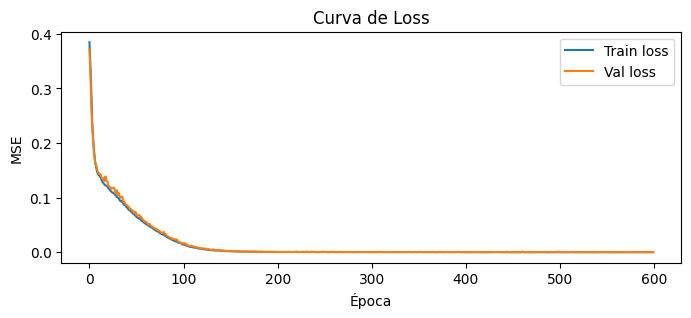

In [5]:
EPOCHS     = 600   # original: 500
BATCH_SIZE = 32    # original: 64

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

# Curva de loss
plt.figure(figsize=(8, 3))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Época'); plt.ylabel('MSE'); plt.legend()
plt.title('Curva de Loss'); plt.show()

## 4. Avaliação — Modelo Float

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Float model  — MAE: 0.0108  RMSE: 0.0158


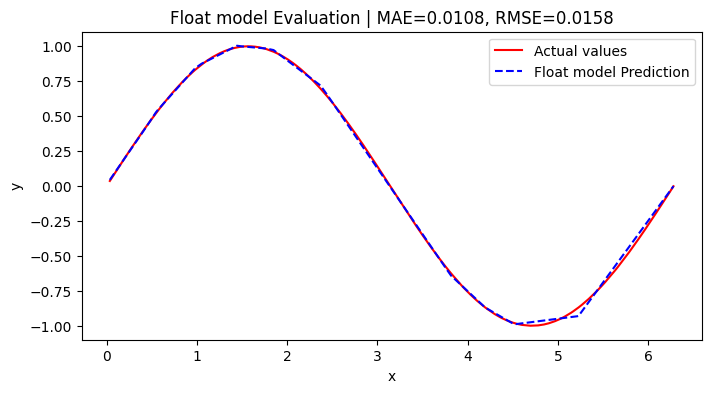

In [6]:
y_pred_float = model.predict(x_test).flatten()
y_true       = np.sin(x_test)   # referência sem ruído

mae_float  = np.mean(np.abs(y_pred_float - y_true))
rmse_float = np.sqrt(np.mean((y_pred_float - y_true) ** 2))

print(f"Float model  — MAE: {mae_float:.4f}  RMSE: {rmse_float:.4f}")

order = np.argsort(x_test)
plt.figure(figsize=(8, 4))
plt.plot(x_test[order], y_true[order],        'r-',  label='Actual values')
plt.plot(x_test[order], y_pred_float[order],  'b--', label='Float model Prediction')
plt.title(f'Float model Evaluation | MAE={mae_float:.4f}, RMSE={rmse_float:.4f}')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()

## 5. Conversão para TFLite (int8)

In [7]:
SAVE_DIR = '/tmp/hello_world_models'
os.makedirs(SAVE_DIR, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

x_rep = np.linspace(0, 2 * math.pi, 500).astype(np.float32)

def representative_dataset():
    for v in x_rep:
        yield [np.array([v], dtype=np.float32)]

converter.representative_dataset    = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8

tflite_model = converter.convert()

tflite_path = os.path.join(SAVE_DIR, 'model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"Modelo salvo: {tflite_path}")
print(f"Tamanho: {len(tflite_model)} bytes")

INFO:tensorflow:Assets written to: /var/folders/js/7h93cvsn367b2v9m5p6k9cgw0000gn/T/tmpxzsm8wji/assets


INFO:tensorflow:Assets written to: /var/folders/js/7h93cvsn367b2v9m5p6k9cgw0000gn/T/tmpxzsm8wji/assets


Saved artifact at '/var/folders/js/7h93cvsn367b2v9m5p6k9cgw0000gn/T/tmpxzsm8wji'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  4708690128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4708693200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4708694928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4708695120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4708695504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4708695888: TensorSpec(shape=(), dtype=tf.resource, name=None)


/Users/emanoelspanhol/Pojetos/IAEmbarcada/Projeto2/hello_world_tflite/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778454358.575793   21655 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778454358.575803   21655 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1778454358.575994   21655 reader.cc:83] Reading SavedModel from: /var/folders/js/7h93cvsn367b2v9m5p6k9cgw0000gn/T/tmpxzsm8wji
I0000 00:00:1778454358.576220   21655 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778454358.576223   21655 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/js/7h93cvsn367b2v9m5p6k9cgw0000gn/T/tmpxzsm8wji
I0000 00:00:1778454358.577796   21655 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1778454358.578065   2

Modelo salvo: /tmp/hello_world_models/model.tflite
Tamanho: 3464 bytes


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1778454358.972287   21655 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


## 6. Avaliação — Modelo Quantizado (int8)

Quantized model — MAE: 0.0185  RMSE: 0.0237


/Users/emanoelspanhol/Pojetos/IAEmbarcada/Projeto2/hello_world_tflite/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


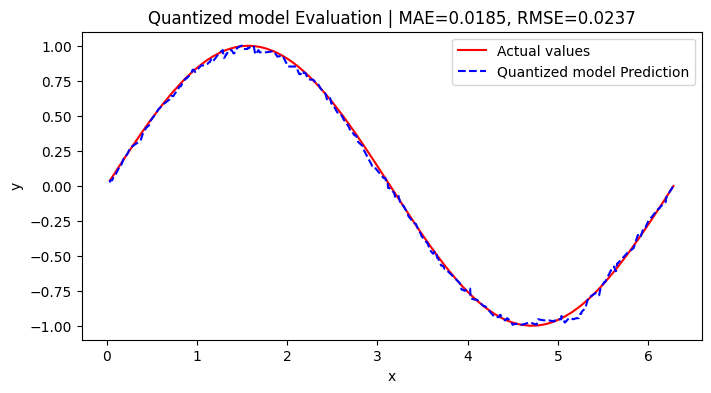

In [8]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

in_scale  = input_details['quantization'][0]
in_zero   = input_details['quantization'][1]
out_scale = output_details['quantization'][0]
out_zero  = output_details['quantization'][1]

y_pred_quant = np.zeros(len(x_test), dtype=np.float32)

for i, xv in enumerate(x_test):
    x_q = np.array([[np.round(xv / in_scale + in_zero)]], dtype=np.int8)
    interpreter.set_tensor(input_details['index'], x_q)
    interpreter.invoke()
    y_q = interpreter.get_tensor(output_details['index'])[0][0]
    y_pred_quant[i] = (float(y_q) - out_zero) * out_scale

mae_quant  = np.mean(np.abs(y_pred_quant - y_true))
rmse_quant = np.sqrt(np.mean((y_pred_quant - y_true) ** 2))

print(f"Quantized model — MAE: {mae_quant:.4f}  RMSE: {rmse_quant:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(x_test[order], y_true[order],        'r-',  label='Actual values')
plt.plot(x_test[order], y_pred_quant[order],  'b--', label='Quantized model Prediction')
plt.title(f'Quantized model Evaluation | MAE={mae_quant:.4f}, RMSE={rmse_quant:.4f}')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()

## 7. Resumo final

In [9]:
print('=== Resumo ===')
print(f'Float model      — MAE: {mae_float:.4f}  RMSE: {rmse_float:.4f}')
print(f'Quantized model  — MAE: {mae_quant:.4f}  RMSE: {rmse_quant:.4f}')
print(f'Degradação MAE:  {(mae_quant - mae_float):.4f}')
print()
print('Para atualizar model.cc no projeto:')
print(f'  xxd -i {tflite_path} > main/model.cc')
print("  Renomeie o array para 'g_model' e adicione 'alignas(8)'")

=== Resumo ===
Float model      — MAE: 0.0108  RMSE: 0.0158
Quantized model  — MAE: 0.0185  RMSE: 0.0237
Degradação MAE:  0.0077

Para atualizar model.cc no projeto:
  xxd -i /tmp/hello_world_models/model.tflite > main/model.cc
  Renomeie o array para 'g_model' e adicione 'alignas(8)'
